# Business Understanding

## Project Domain

Domain: Food & Beverage Industry
Sub-Domain: Quality Control & Product Optimization

Sistem prediksi kualitas wine (Wine Quality Prediction System) berada dalam lingkup industri makanan dan minuman, khususnya dalam pengendalian mutu (quality control). Dengan memanfaatkan data science dan machine learning, perusahaan wine dapat secara otomatis menilai kualitas produk berdasarkan parameter kimia yang terukur, seperti keasaman, kadar alkohol, dan kandungan sulfur. Hal ini memungkinkan produsen untuk mengoptimalkan proses produksi, menjaga konsistensi produk, dan mendukung pengambilan keputusan dalam tahap penyaringan dan pengemasan wine.

## Problem Statements

Masalah yang Dihadapi:

1. Penilaian Kualitas Wine yang Subjektif
Penilaian kualitas wine secara tradisional sering bergantung pada uji rasa manusia (sensory testing) yang bersifat subjektif dan tidak konsisten antar penilai. Hal ini menyulitkan produsen dalam standarisasi kualitas.

2. Kurangnya Sistem Otomatis untuk Pengendalian Mutu
Banyak produsen wine skala kecil belum memiliki sistem otomatis untuk menilai kualitas produk berdasarkan parameter kimia, sehingga proses quality control menjadi lambat dan tidak efisien.

3. Ketergantungan pada Uji Laboratorium Manual
Pengujian laboratorium terhadap atribut kimia wine memerlukan waktu, biaya, dan tenaga ahli. Hal ini tidak ideal untuk produksi besar-besaran yang membutuhkan proses cepat dan hemat biaya.

4. Keterbatasan Data dalam Pengambilan Keputusan Produksi
Tanpa analisis data historis yang memadai, produsen sulit memprediksi bagaimana variasi dalam komposisi kimia akan memengaruhi kualitas akhir, yang dapat menyebabkan hasil produksi yang tidak konsisten.



## Goals

Membangun sistem prediksi kualitas wine berbasis AI (Artificial Neural Network / TensorFlow Lite) yang mampu mengklasifikasikan tingkat kualitas wine berdasarkan parameter kimia, seperti:

- Fixed Acidity
- Volatile Acidity
- Citric Acid
- Residual Sugar
- Chlorides
- Free Sulfur Dioxide & Total Sulfur Dioxide
- Density
- pH
- Sulphates
- Alcohol Content

Sistem ini ditujukan untuk mendukung proses quality control, standarisasi produk, dan pengambilan keputusan produksi secara otomatis dan efisien dalam industri wine.

## Solution Statements

- Model Machine Learning (Artificial Neural Network)
Membangun model klasifikasi berbasis Artificial Neural Network (ANN) untuk memprediksi tingkat kualitas wine (skala 0–10) berdasarkan parameter kimia dari proses produksi. Model dilatih menggunakan data historis untuk mencapai akurasi tinggi dalam penilaian kualitas.

- Aplikasi Web (Streamlit)
Mengembangkan aplikasi web interaktif menggunakan Streamlit yang memungkinkan produsen atau analis mutu untuk memasukkan nilai-nilai parameter kimia dan langsung mendapatkan prediksi kualitas wine secara instan.

- Optimasi dengan TensorFlow Lite
Model dikonversi ke format TensorFlow Lite agar dapat dijalankan secara ringan pada perangkat edge (misalnya tablet, smartphone, atau sistem produksi terintegrasi) untuk memudahkan adopsi di lapangan tanpa memerlukan komputasi tinggi.

# Data Understanding

## Import data dari kaggle

In [55]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fachrizalkurnianto","key":"9a66a0a1214859f21ff1a3df8bd284ff"}'}

In [56]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d subhajournal/wine-quality-data-combined

Dataset URL: https://www.kaggle.com/datasets/subhajournal/wine-quality-data-combined
License(s): GNU Affero General Public License 3.0


In [4]:
!mkdir wine-quality-data-combined
!unzip wine-quality-data-combined.zip -d wine-quality-data-combined
!ls wine-quality-data-combined

Archive:  wine-quality-data-combined.zip
  inflating: wine-quality-data-combined/WineQuality.csv  
WineQuality.csv


## Import Library yang dibutuhkan

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [58]:
df = pd.read_csv('/content/wine-quality-data-combined.zip')

In [59]:
df.head()

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type
0,2732,7.4,0.170,0.29,1.4,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,White Wine
1,2607,5.3,0.310,0.38,10.5,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,White Wine
2,1653,4.7,0.145,0.29,1.0,0.042,35.0,90.0,0.99080,3.76,0.49,11.3,6,White Wine
3,3264,6.9,0.260,0.29,4.2,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,White Wine
4,4931,6.4,0.450,0.07,1.1,0.030,10.0,131.0,0.99050,2.97,0.28,10.8,5,White Wine


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32485 entries, 0 to 32484
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            32485 non-null  int64  
 1   fixed acidity         32485 non-null  float64
 2   volatile acidity      32485 non-null  float64
 3   citric acid           32485 non-null  float64
 4   residual sugar        32485 non-null  float64
 5   chlorides             32485 non-null  float64
 6   free sulfur dioxide   32485 non-null  float64
 7   total sulfur dioxide  32485 non-null  float64
 8   density               32485 non-null  float64
 9   pH                    32485 non-null  float64
 10  sulphates             32485 non-null  float64
 11  alcohol               32485 non-null  float64
 12  quality               32485 non-null  int64  
 13  Type                  32485 non-null  object 
dtypes: float64(11), int64(2), object(1)
memory usage: 3.5+ MB


In [61]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)

In [62]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type
0,7.4,0.170,0.29,1.4,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,White Wine
1,5.3,0.310,0.38,10.5,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,White Wine
2,4.7,0.145,0.29,1.0,0.042,35.0,90.0,0.99080,3.76,0.49,11.3,6,White Wine
3,6.9,0.260,0.29,4.2,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,White Wine
4,6.4,0.450,0.07,1.1,0.030,10.0,131.0,0.99050,2.97,0.28,10.8,5,White Wine


<ipython-input-63-f37dea1564b0>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax = ax)
<ipython-input-63-f37dea1564b0>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax = ax)
<ipython-input-63-f37dea1564b0>:6: UserWarning: 

`distplot` is a deprecated function and will be 

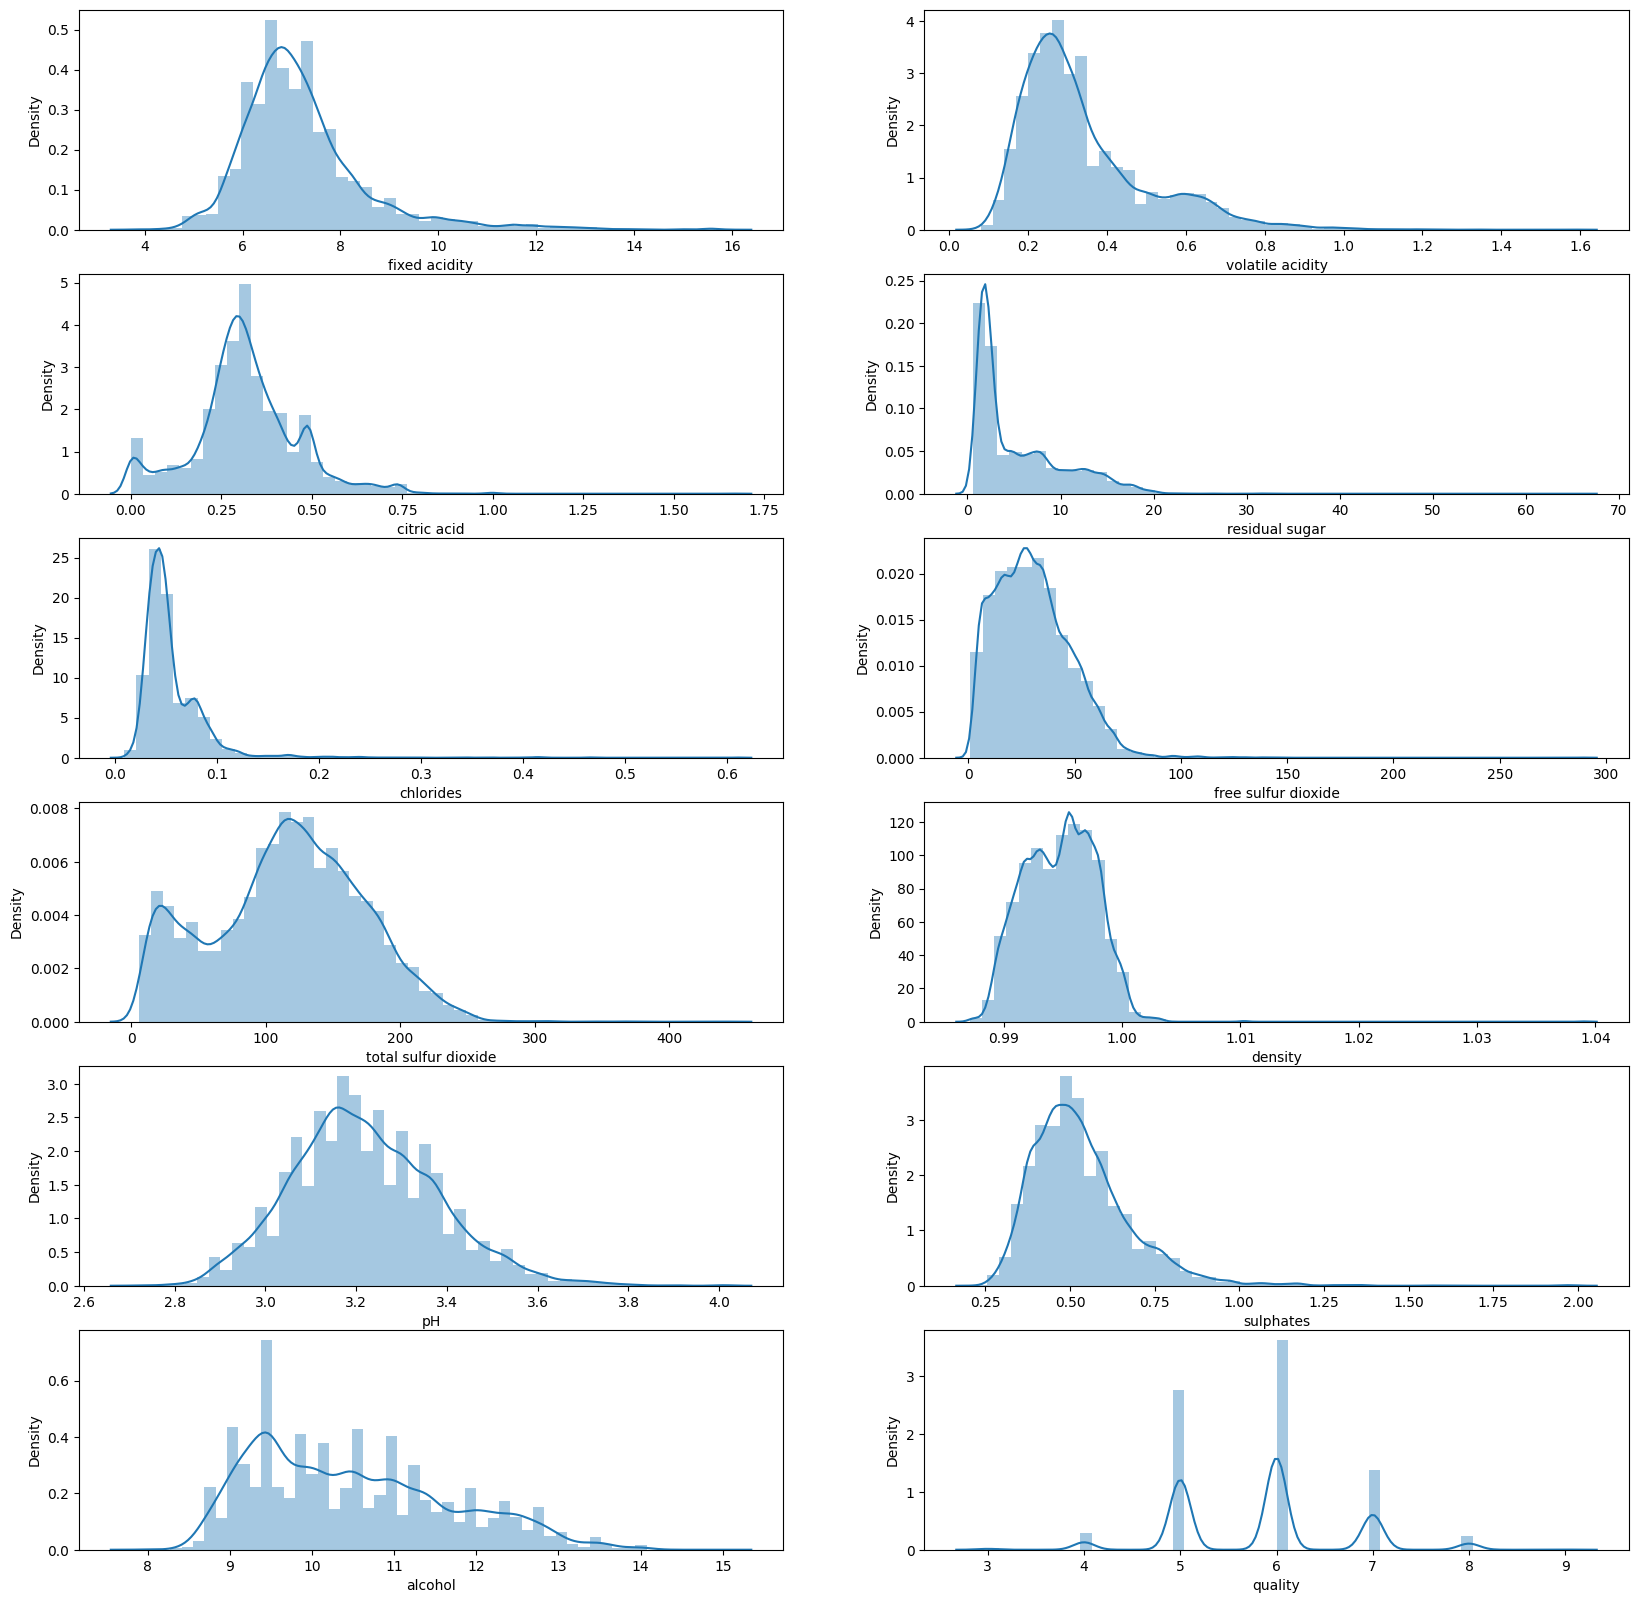

In [63]:
fig, axes = plt.subplots(nrows = 6, ncols = 2)
axes = axes.flatten()
fig.set_size_inches(20,20)

for ax, col in zip(axes, df.columns):
  sns.distplot(df[col], ax = ax)

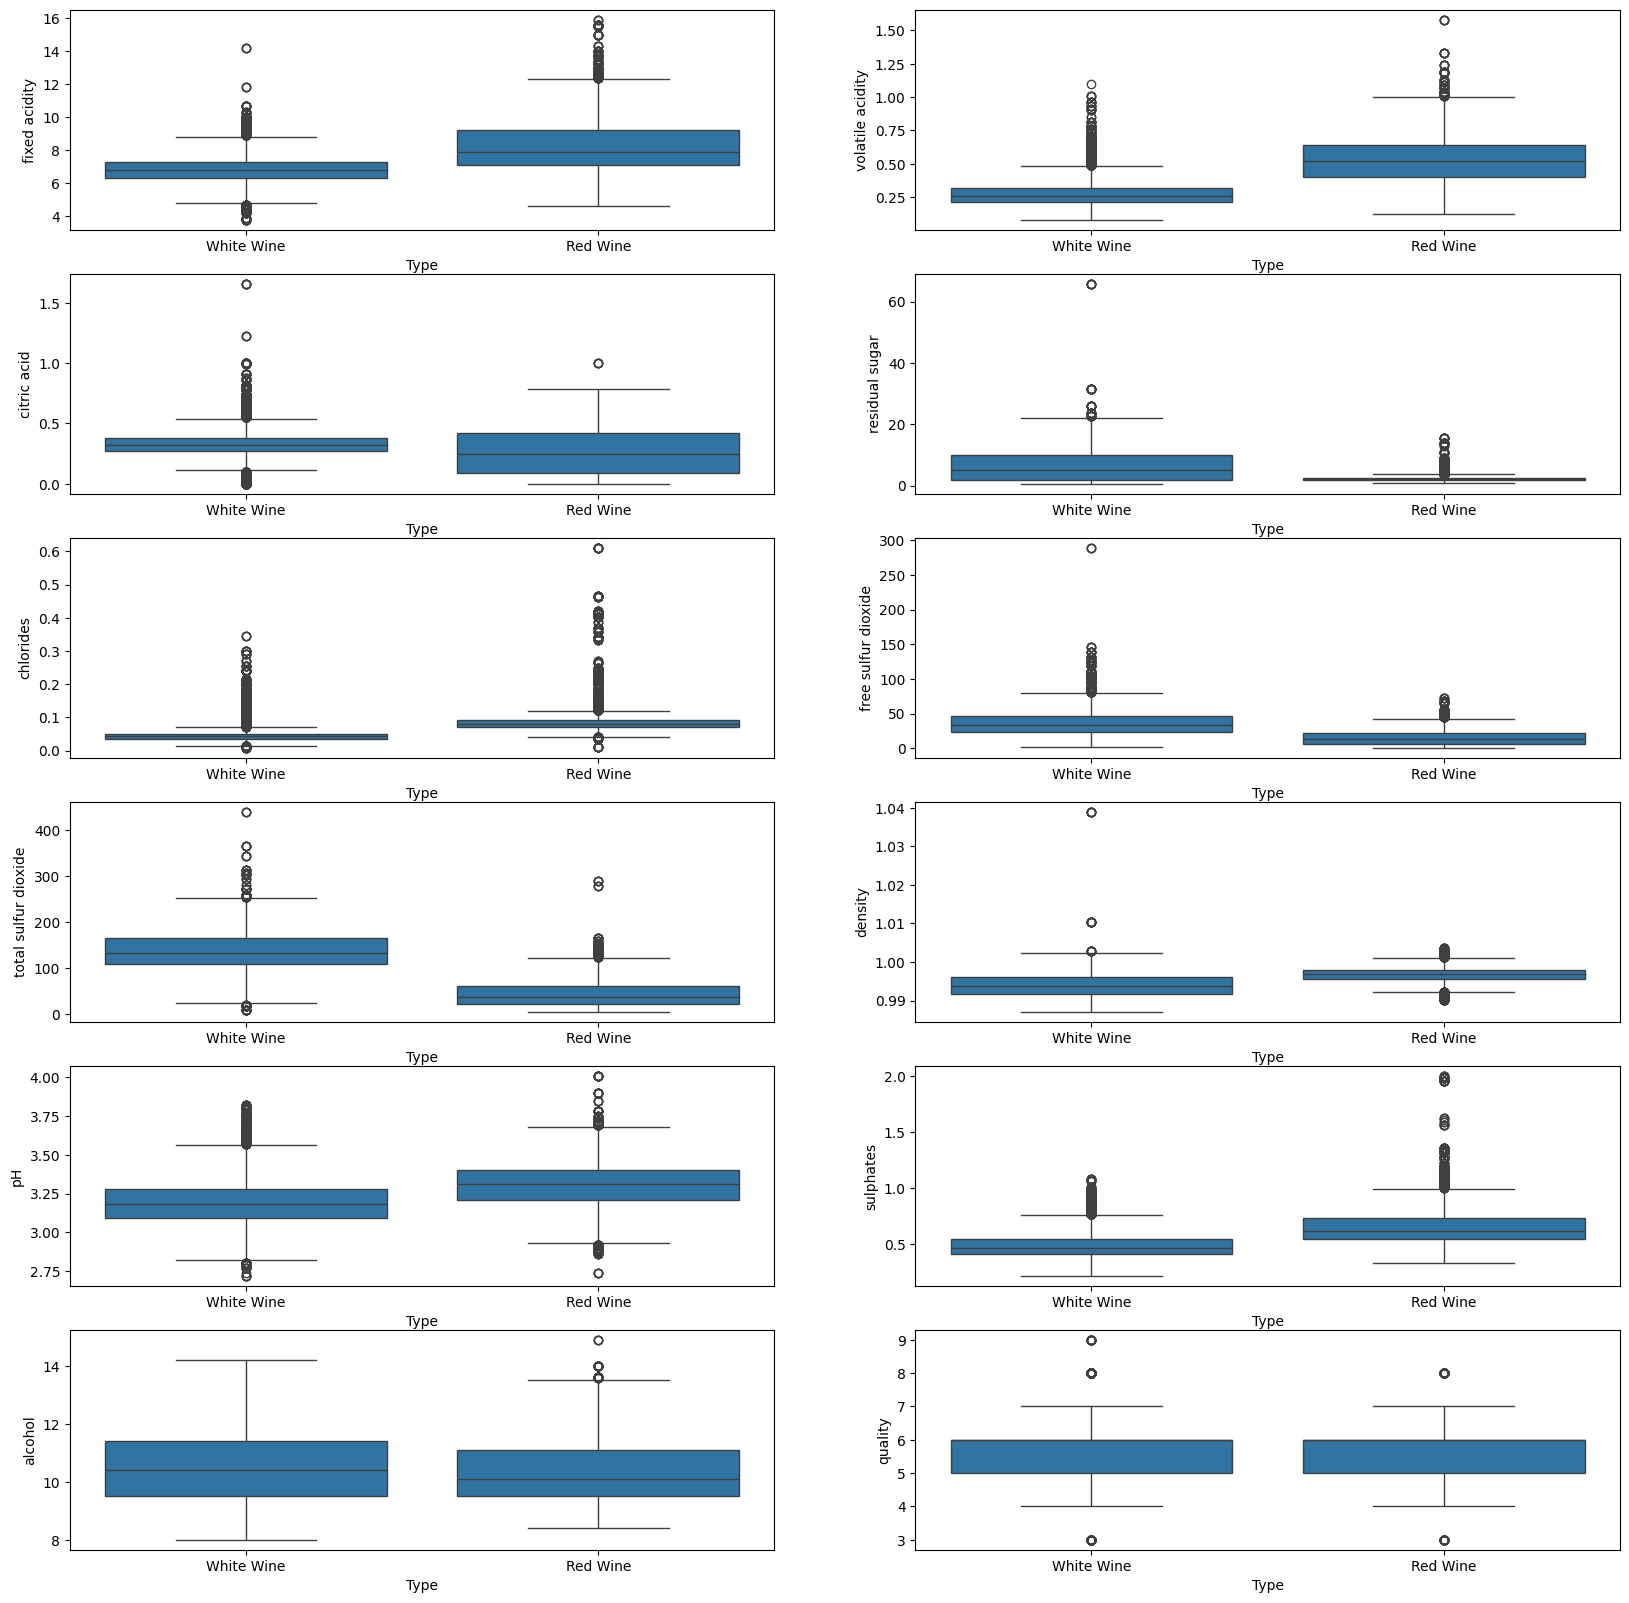

In [64]:
fig, axes = plt.subplots(nrows = 6, ncols = 2)
axes = axes.flatten()
fig.set_size_inches(20,20)

for ax, col in zip(axes, df.columns):
  sns.boxplot(x='Type',y=df[col], ax = ax , data=df)

<Axes: xlabel='alcohol', ylabel='fixed acidity'>

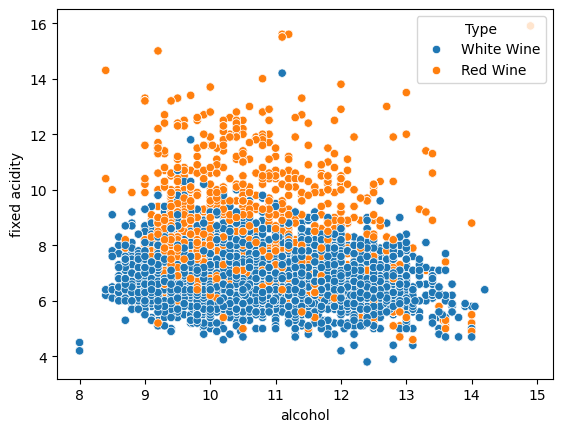

In [65]:
sns.scatterplot(x='alcohol', y='fixed acidity', hue='Type', data=df)

<Axes: xlabel='citric acid', ylabel='volatile acidity'>

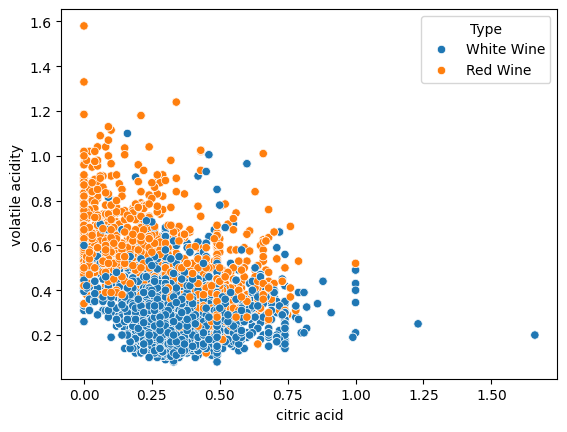

In [66]:
sns.scatterplot(x='citric acid', y='volatile acidity', hue='Type', data=df)

<Axes: xlabel='free sulfur dioxide', ylabel='total sulfur dioxide'>

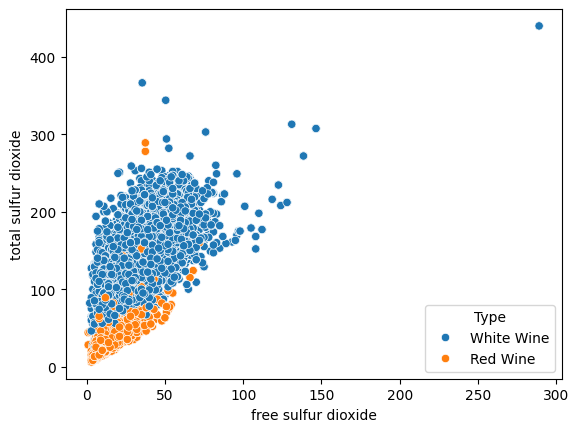

In [67]:
sns.scatterplot(x='free sulfur dioxide', y='total sulfur dioxide', hue='Type', data=df)

<Axes: xlabel='density', ylabel='pH'>

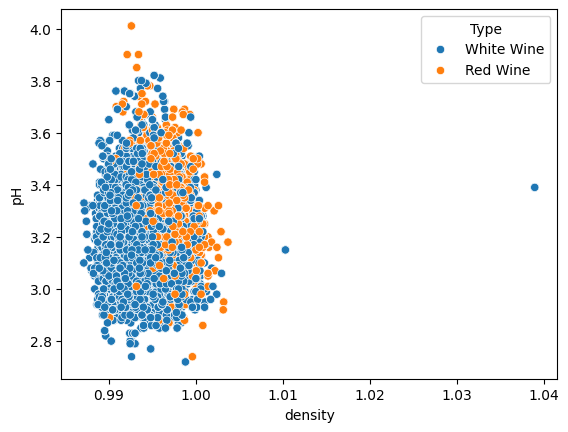

In [68]:
sns.scatterplot(x='density', y='pH', hue='Type', data=df)

# Data Preparation

In [69]:
# pisahkan fitur dan target
X = df.drop(columns=["Type"])
y = df["Type"]

In [70]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [71]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [72]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [73]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [74]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy", # Changed loss function
              metrics=["accuracy"])

In [75]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,066 (47.13 KB)

 Trainable params: 12,066 (47.13 KB)

 Non-trainable params: 0 (0.00 B)

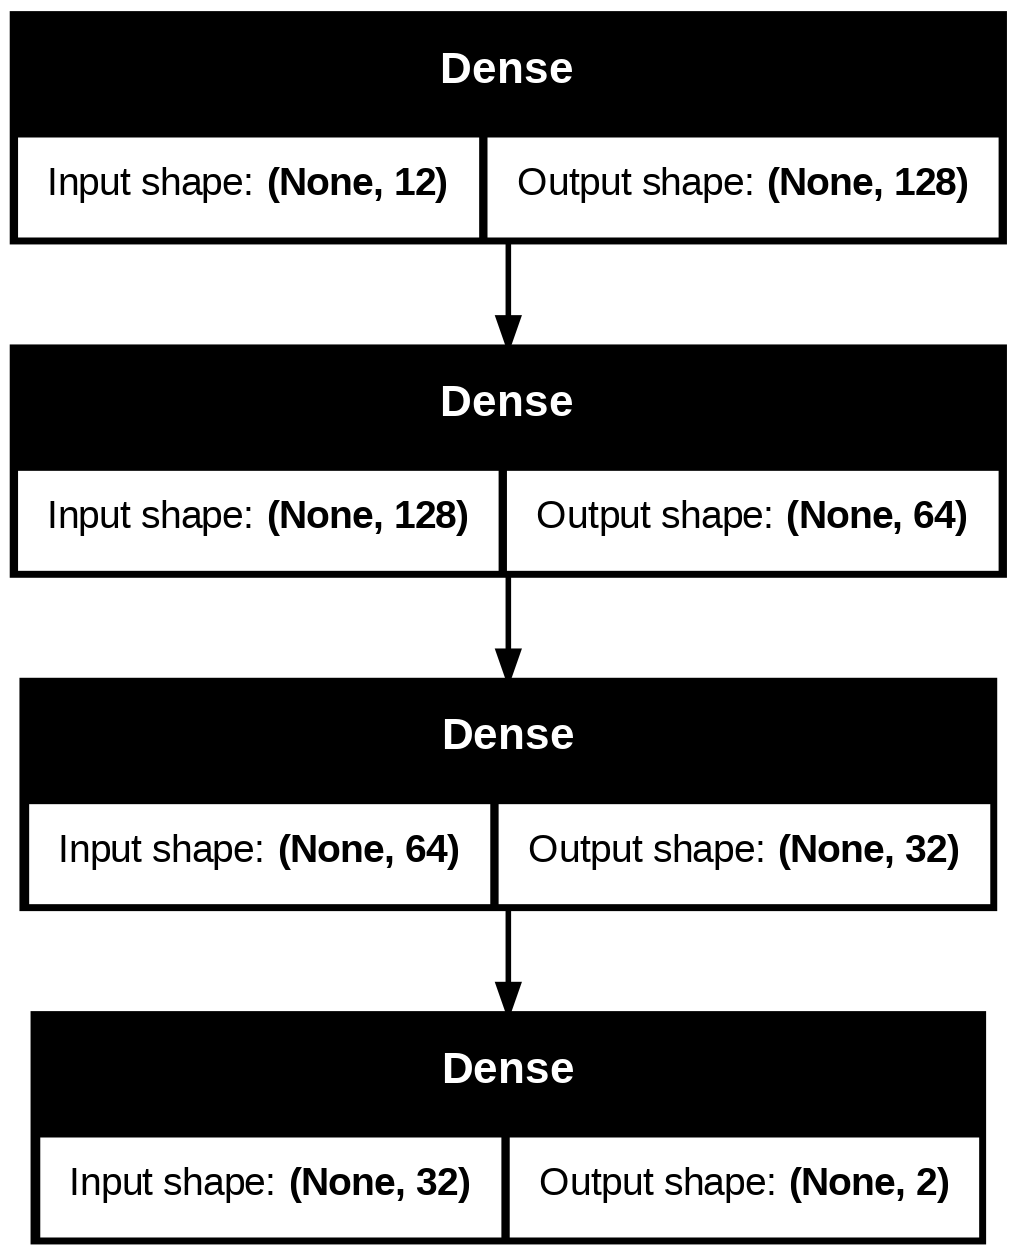

In [76]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [77]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9578 - loss: 0.1090 - val_accuracy: 0.9918 - val_loss: 0.0294
Epoch 2/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9944 - loss: 0.0228 - val_accuracy: 0.9943 - val_loss: 0.0274
Epoch 3/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9947 - loss: 0.0243 - val_accuracy: 0.9958 - val_loss: 0.0191
Epoch 4/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9963 - loss: 0.0171 - val_accuracy: 0.9952 - val_loss: 0.0179
Epoch 5/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9954 - loss: 0.0188 - val_accuracy: 0.9925 - val_loss: 0.0257
Epoch 6/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9956 - loss: 0.0187 - val_accuracy: 0.9946 - val_loss: 0.0229
Epoch 7/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9970 - loss: 0.0150 - val_accuracy: 0.9960 - val_loss: 0.0147
Epoch 8/50
1625/1625 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9966 - loss: 0.0141 -

# Evaluation

In [78]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9997 - loss: 0.0030
Akurasi Model: 0.9992
Loss Model: 0.0031


In [79]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

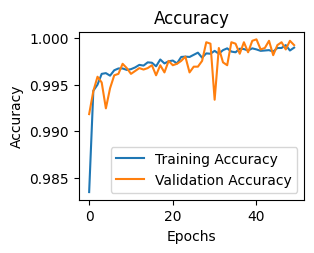

In [80]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

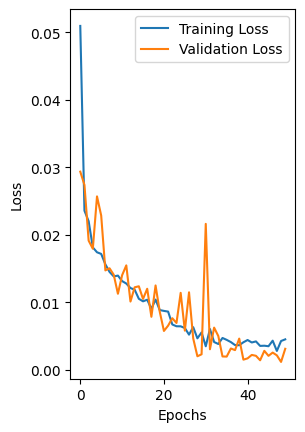

In [81]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


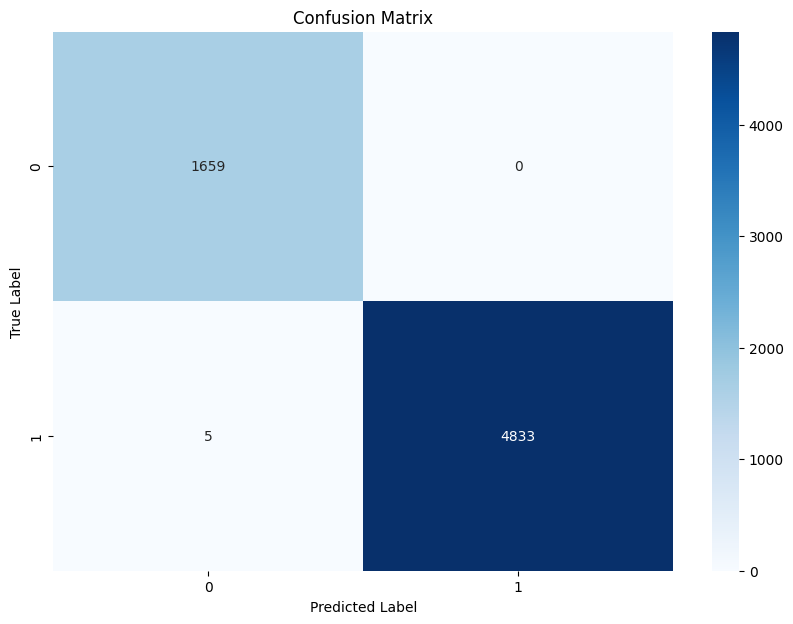

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1659
           1       1.00      1.00      1.00      4838

    accuracy                           1.00      6497
   macro avg       1.00      1.00      1.00      6497
weighted avg       1.00      1.00      1.00      6497



In [82]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [83]:
sample_input = np.array([[7.4, 0.170, 0.29, 1.4, 0.047,	23.0, 107.0, 0.99390, 3.52, 0.65, 10.4, 6]])
sample_input_df = pd.DataFrame(sample_input)

In [84]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [85]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Wine yang direkomendasikan: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Wine yang direkomendasikan: White Wine


## Save Model

In [86]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('wine_recommendation.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpifu6gt2u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  132994871948496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994871947152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132996584796816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132996584794896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994869836112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994869836304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994869834960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994869837072: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [87]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']